# Compulsory Assignment 3: Semantic segmentation

Please fill out the the group name, number, members and optionally the name below.

**Group number**: Group 2 \
**Group member 1**: Kristian Mathias Røhne\
**Group member 2**: Simen Roko Krogstie\
**Group member 3**: Erling Hamil Mysen\
**Group name (optional)**: The Three Musk(eteers)


# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. This is the biggest assignment of the semester, and therefore you get two weeks to work on it. However, we reccomend that **you start early**. This assignment has three semi-big sections, each of which build upon the last. So if you delay the assignment until the day before submission, you will most likely fail. This assignment is completed by doing the following.
* Submit notebook as an .ipynb file to canvas.
* Submit notebook as an .pdf file to canvas.
* Submit the python script you run on ORION to canvas.
* Submit the SLURM script you run on ORION to canvas.
* Submit at least one of your model predictions to the Kaggle leaderboard, and attain a score that is higher than the *BEAT ME* score.

NOTE: Remember to go through the rules given in the lecture "Introduction to compulsory assignments", as there are many do's and dont's with regard to how you should present the work you are going to submit.


# Introduction
In the context of transportation, pilots need to identify possible urgent landing areas in forests.
Therefore, scientists have provided us with aerial photos of the forest and accompanying image
masks that indicate the presence of birch trees in the images. These masks are binary, with a value of
0 representing areas without birch trees and a value of 1 indicating the presence of birch trees. Our
objective is to utilize this dataset to train a model capable of performing semantic segmentation,
accurately identifying and delineating birch trees in the images.

## Dataset
In this assigmnet you will be given 3200 annotated images. The image, and mask dimensions are 128x128 pixels. With each image there follows an annotation mask where each pixel is classified as `1` (birch tree occurence) or `0` (not birch tree) The test-dataset contains 800 images, where no ground truth masks are given. To evaluate your model on the test dataset, submit your predictions to the Kaggle leaderboard.

## Assignment tasks

1. Familiarising: Before any modelling, visualise examples of the raw data and masks in
your Jupyter notebook.
2. Basic U-NET: Create a U-Net with optional dropout. Use a proportion of the images
for validation when training. The minimum requirement is to tune the following
parameters: number of convolutional filters, dropout and learning rate. Report
strategies and scores leading up to the final choice.
3. I recommend adding augmentation (both images and masks) and changing the loss
function, e.g. implementing F1 loss. Create a plot showing your model's predicted
mask on some images in the training set and compare to the correct mask.
4. Transfer learning: Create a U-Net where the encoder part of the U-Net uses a pretrained VGG16 (or some other similar pre-trained model)
3. This can be achieved by loading a pre-trained model, dropping the final layer and
freezing the weights. Add skip connections from the Conv2D layers of the VGG16-
based encoder to the expansion layers of the decoder.


## Submissions to the Kaggle leaderboard

Link to the Kaggle leaderboard will be posted in the Canvas assignment.

```python
y_pred      = model.predict(X_test)                       # Make prediction
flat_y_pred = y_pred.flatten()                            # Flatten prediction
flat_y_pred[flat_y_pred >= USER_DETERMINED_THRESHOLD] = 1 # Binarize prediction (Optional, depends on output activation used)
flat_y_pred[flat_y_pred != 1]   = 0                       # Binarize prediction (Optional, depends on output activation used)
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_y_pred))              # The submission csv file must have a column called 'ID'
submissionDF['Prediction'] = flat_y_pred
submissionDF.to_csv('submission.csv', index=False)        # Remember to store the dataframe to csv without the nameless index column.
```

# Library imports
Feel free to import other packages as needed.

In [ ]:
# Importing necessary packages
import time
from tqdm import tqdm  # Cool progress bar
import random
import numpy as np
import h5py
import cv2
import re
from IPython.display import Image
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import pandas as pd

import tensorflow as tf
import keras as ks
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import FalseNegatives, FalsePositives, TrueNegatives, TruePositives, MeanMetricWrapper

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.applications import VGG16
from keras.layers import Input, Conv2DTranspose, Conv2D, Dropout, MaxPooling2D, concatenate
from keras.models import Model, load_model

# Custom imports
from visualization import *
from utilities import *



# Data loading

Load the data from the HDF5 file `tree_train.h5` and `tree_test.h5` that is available on Canvas, and Kaggle.
The data should be loaded in the same manner as in CA2.

In [ ]:
# Loading the dataset

FILE_PATH = "tree_train.h5"

with h5py.File(FILE_PATH,'r') as f:
    print('Datasets in file:', list(f.keys()))
    X = f['X'][:]
    y = f['y'][:]

# Verify the shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

Datasets in file: ['X', 'y']
X shape: (3200, 128, 128, 3)
y shape: (3200, 128, 128, 1)


In [ ]:
# Loading the test data
FILE_PATH = "tree_test.h5"

with h5py.File(FILE_PATH,'r') as f:
    print('Datasets in file:', list(f.keys()))
    X_test = f['X'][:]

# Verify the shapes of X and y
print("X_test shape:", X_test.shape)

Datasets in file: ['X']
X_test shape: (800, 128, 128, 3)


# Visualization

Plot a few samples images and masks. \
Feel free to visualize any other aspects of the dataset that you feel are relevant.

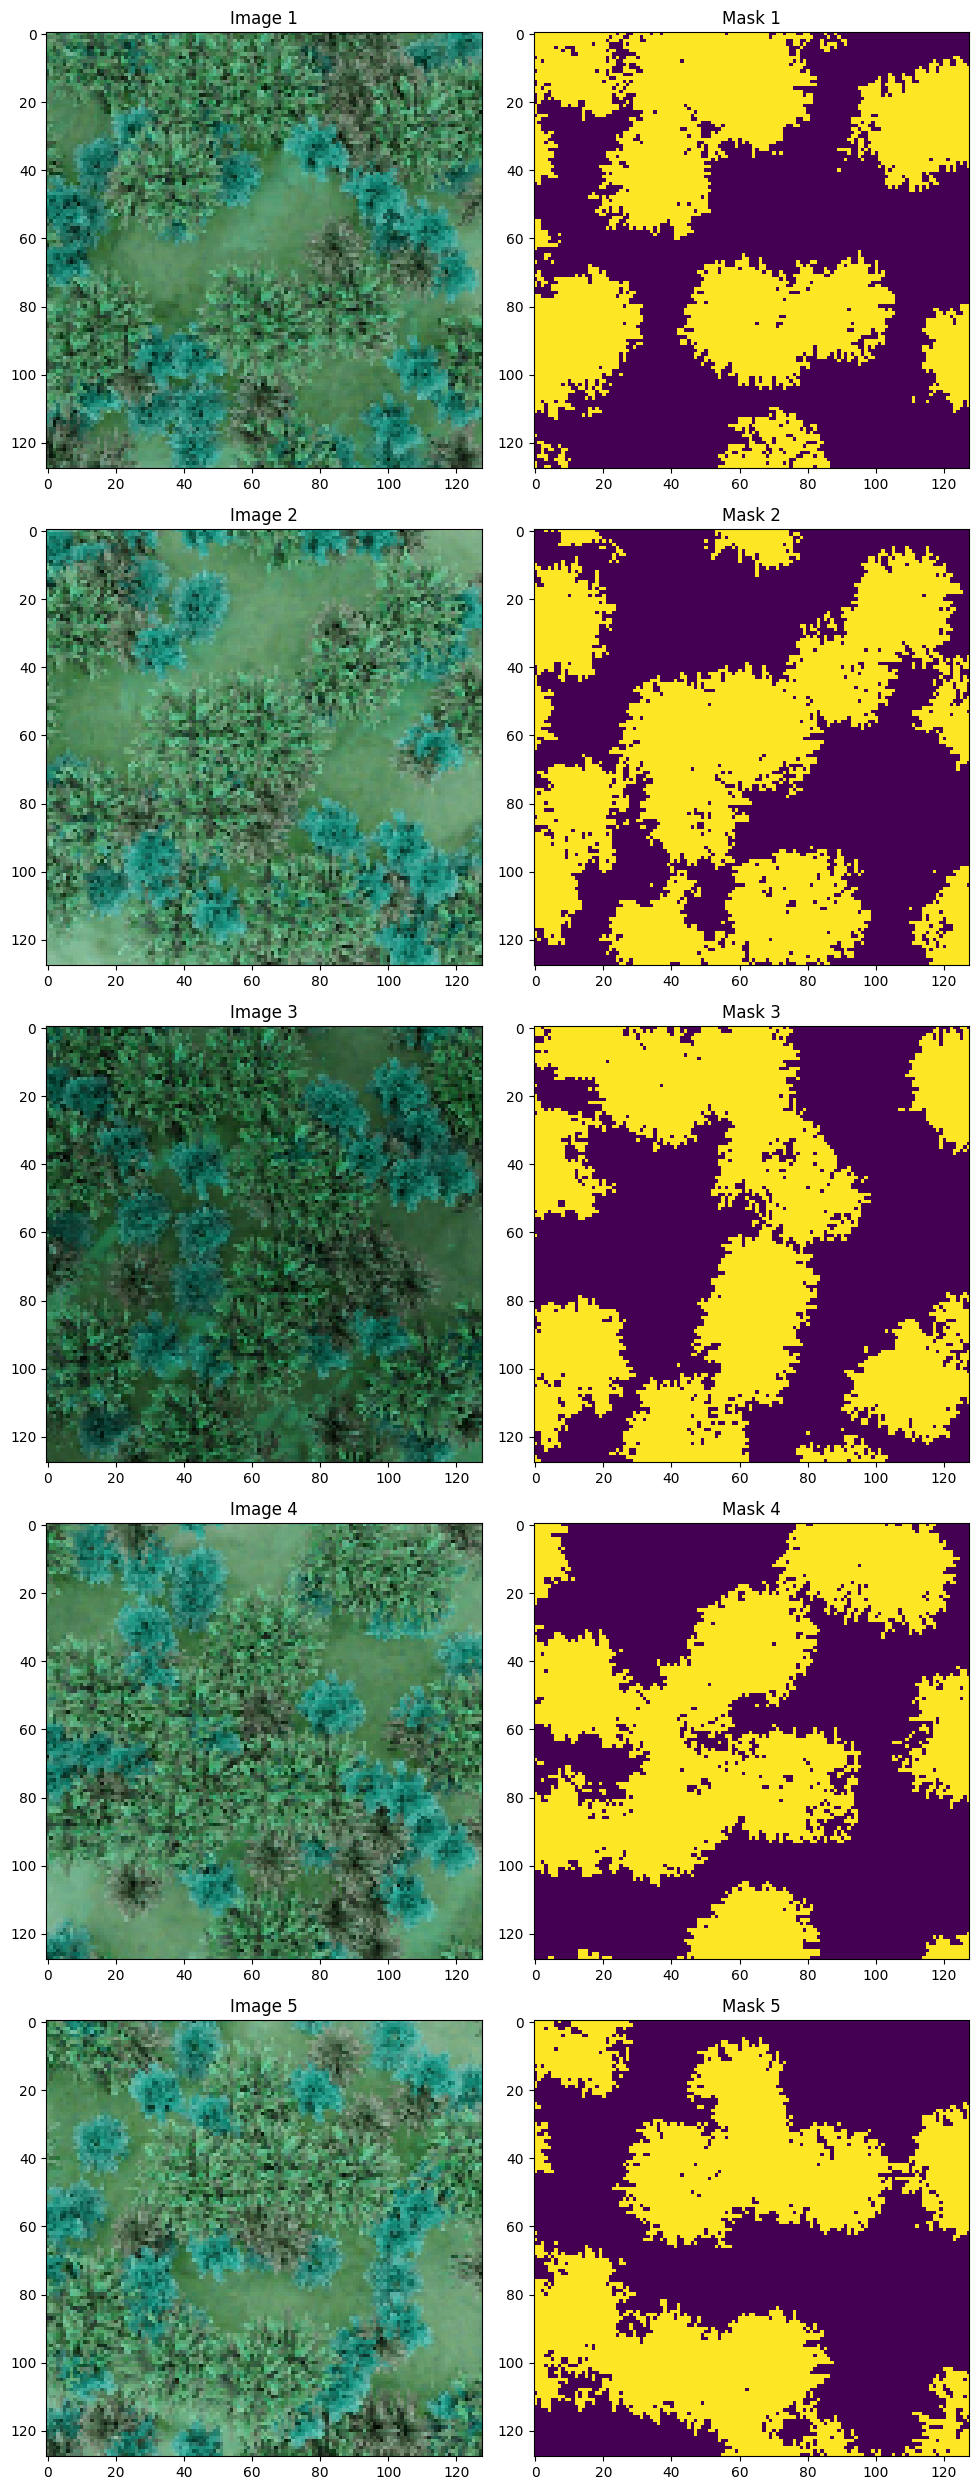

In [ ]:
# Plot samples of images with their corresponding mask
num_samples = 5  

fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 5))
for i in range(num_samples):
    # Plot of image
    axes[i, 0].imshow(X[i])
    axes[i, 0].set_title(f"Image {i+1}")
    # Plot of mask
    axes[i, 1].imshow(y[i])
    axes[i, 1].set_title(f"Mask {i+1}")

plt.tight_layout()
plt.show()

# Preprocessing

Preprocess the dataset in whatever ways you think are helpful. \
Tips: Perhaps you preprocess the different models in different ways?

In [ ]:
# Normalizing pixel values between 0 and 1
X = X / 255.0
X_test = X_test / 255.0

# Splitting the dataset in training and validation sets (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Converting mask labels to flaot32
y_train = y_train.astype('float32')
y_val = y_val.astype('float32')

# Setting augmentation parameters for both images and masks
data_gen_args = dict(rotation_range=10,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     shear_range=0.1,
                     zoom_range=0.1,
                     horizontal_flip=True,
                     fill_mode='nearest')

# Initializing generators to apply identical augemtations to images and masks
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Fitting generators on the training data
image_datagen.fit(X_train)
mask_datagen.fit(y_train)

# Part 1: Implementing U-net

## Intersection over Union

The IoU score is a popular metric in both segmentation and object detection problems.

If you want to use the `plot_training_history` function in the `visualization.py` library remember to compile the model with the TP, TN, FP, FN metrics such that you can estimate the *Intersection-over-Union*. **However, it is voluntary to estimate IoU**

See example below:

```python
from tensorflow.keras.metrics import FalseNegatives, FalsePositives, TrueNegatives, TruePositives
from utilities import F1_score,
from visualization import plot_training_history,
...
model.compile(optimizer='Something',
                  loss='Something else',
                  metrics=[FalseNegatives(),
                           FalsePositives(),
                           TrueNegatives(),
                           TruePositives(),
                           F1_score,
                           OtherMetricOfChoice])

training_history = model.fit(X_train, y_train, ...)
plot_training_history(training_history)
```

You have also been provided with a custom F1-score metric in the `utilities.py` library, which is specific for image segmentation. **This is mandatory to use when compiling the model**.


## Task 1.1 Model implementation

Implement the classical U-net structure that you have learned about in the lectures. Feel free to experiment with the number of layers, loss-function, batch-normalization, etc. **Remember to compile with the F1-score metric**.


In [ ]:
# Wrapping the F1_score function, allowing Keras to compute and track the F1 score during training. 
f1_metric = MeanMetricWrapper(F1_score, name="f1_score")

### U-net

In [ ]:
# Function for building the U-net
def build_unet_model(filters, dropout_rate, learning_rate, list_of_metrics):

    # Defining the inputlayer dimensions
    inputs = Input((128, 128, 3))

    # Encoder/Downsampling 
    # First block in the encoder with convolution, dropout and pooling layers for downsampling
    c1 = Conv2D(filters, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Dropout(dropout_rate)(c1)
    c1 = Conv2D(filters, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Second block in the encoder doubling the number of filters in the convolutional layers and further downsampling with pooling layer
    c2 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(p1)
    c2 = Dropout(dropout_rate)(c2)
    c2 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bottleneck that quadrupple the number of filters, 
    # capturing the most abstract features in the data
    c3 = Conv2D(filters * 4, (3, 3), activation='relu', padding='same')(p2)
    c3 = Dropout(dropout_rate)(c3)
    c3 = Conv2D(filters * 4, (3, 3), activation='relu', padding='same')(c3)

    # Decoder/Upsampling
    # First block in the decoder with transposed convolution to upsample and concatenate with 
    # the output from the encoder
    u2 = Conv2DTranspose(filters * 2, (2, 2), strides=(2, 2), padding='same')(c3)
    u2 = concatenate([u2, c2])
    c4 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(u2)
    c4 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(c4)

    # Second block in the decoder with transposed convolution for further upsampling, and concatenation
    u1 = Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding='same')(c4)
    u1 = concatenate([u1, c1])
    c5 = Conv2D(filters, (3, 3), activation='relu', padding='same')(u1)
    c5 = Conv2D(filters, (3, 3), activation='relu', padding='same')(c5)

    # Output layer with one filter for binary segmentation
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    # Defining U-net model with the input and output layers
    model = Model(inputs=[inputs], outputs=[outputs])

    # Compile the model with custom metrics
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics= list_of_metrics
    )
    
    return model

In [ ]:
# Defining parameter grid for model configuration, lines that are commented out are the parameter grids used during
# hyperparameter tuning. The ones not commented out, are the hyperparameters that performed best toghether, and therefore 
# are being used for the model. 

#filters_options = [8, 16, 24,32, 64]
filters_options = [64]

#dropout_rate_options = [0.1, 0.2]
dropout_rate_options = [0.2]

#learning_rate_options = [1e-2, 1e-3, 1e-4]
learning_rate_options = [1e-3]

# Defining metrics to measure model performance
metrics = [FalseNegatives(),
                           FalsePositives(),
                           TrueNegatives(),
                           TruePositives(),
                           f1_metric]

In [ ]:
# Hyperparameter tuning

# Initializing a list to store results for each iteration in the tuning
results = []

# For-loop iterating over all combinations of the hyperparameters
for filters, dropout_rate, learning_rate in itertools.product(filters_options, dropout_rate_options, learning_rate_options):
    # Building a U-net model instance with the current combination of hyperparameters
    model = build_unet_model(filters=filters,
                             dropout_rate=dropout_rate,
                             learning_rate=learning_rate,
                             list_of_metrics = metrics)

    # Training the model on training data and validating on validation data.
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=16, verbose=0)

    # Evaluating the model on the validation set with the current combination of hyperparameters
    val_f1_score = history.history['val_f1_score'][-1]

    # Appending the current configurations and corresponding validation F1 score to results.
    results.append({
        'filters': filters,
        'dropout_rate': dropout_rate,
        'learning_rate': learning_rate,
        'val_f1_score': val_f1_score
    })

# Finding the best configuration based on the validation F1 score
best_config = max(results, key=lambda x: x['val_f1_score'])
print("Best configuration:", best_config)

Best configuration: {'filters': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'val_f1_score': 0.927165687084198}


In [ ]:
# Building the U-Net model using the hyperparameters that performed 
# best during hyperparameter tuning. 
best_model = build_unet_model(
    filters=best_config['filters'],
    dropout_rate=best_config['dropout_rate'],
    learning_rate=best_config['learning_rate'],
    list_of_metrics = metrics
)

## Task 1.2 Train the model, and plot the training history
Feel free to use the `plot_training_history` function from the provided library `utilities.py`

### Training the model

In [ ]:
# Training the best U-Net model
training_history = best_model.fit(
    X_train, y_train,                   # Training data 
    validation_data=(X_val, y_val),     # Validation data
    epochs=5,                           # Number of epochs (Used 20 epochs for the Kaggle submission)
    batch_size=16                       # Batch size
)

Epoch 1/5
160/160 [==============================] - 181s 1s/step - loss: 0.1134 - false_negatives: 940715.0000 - false_positives: 1040149.0000 - true_negatives: 21861644.0000 - true_positives: 18100526.0000 - f1_score: 0.9481 - val_loss: 0.1077 - val_false_negatives: 197256.0000 - val_false_positives: 273226.0000 - val_true_negatives: 5445405.0000 - val_true_positives: 4569873.0000 - val_f1_score: 0.9510
Epoch 2/5
160/160 [==============================] - 22s 136ms/step - loss: 0.1106 - false_negatives: 920143.0000 - false_positives: 1013915.0000 - true_negatives: 21887888.0000 - true_positives: 18121104.0000 - f1_score: 0.9493 - val_loss: 0.1060 - val_false_negatives: 200607.0000 - val_false_positives: 261033.0000 - val_true_negatives: 5457598.0000 - val_true_positives: 4566522.0000 - val_f1_score: 0.9519
Epoch 3/5
160/160 [==============================] - 22s 136ms/step - loss: 0.1080 - false_negatives: 898881.0000 - false_positives: 990540.0000 - true_negatives: 21911256.0000 - t

### Plotting performance

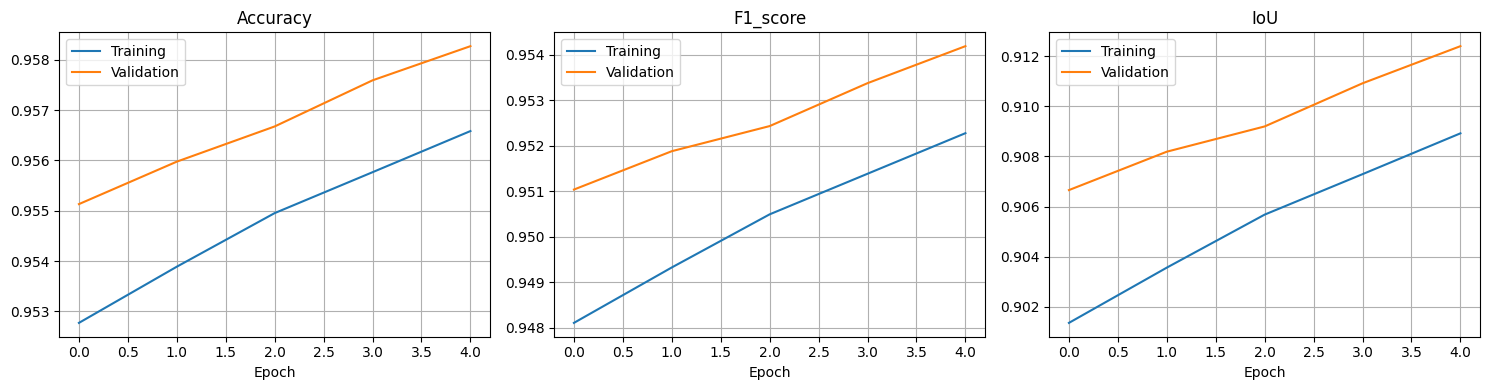

In [ ]:
# Ploting the training history
plot_training_history(training_history)

## Task 1.3 Visualize model predictions

Make a plot that illustrates the original image, the predicted mask, and the ground truth mask.

### Plotting

1/1 [==============================] - 1s 520ms/step


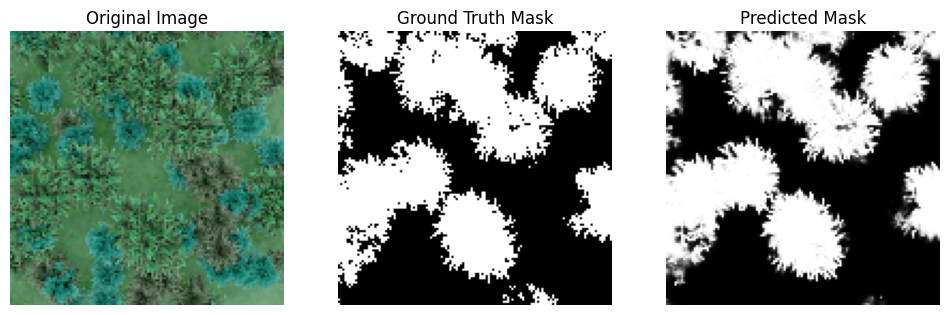

In [ ]:
# Select a sample from the validation set
sample_index = 0                        # Index of the image to be viewed
original_image = X_val[sample_index]    
ground_truth_mask = y_val[sample_index]

# Generating a predicted mask for the selected image, using the trained U-Net
predicted_mask = best_model.predict(original_image[None, ...])[0]


# Plotting the original image, ground truth mask and predicted mask
plt.figure(figsize=(12, 4))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Ground Truth Mask
plt.subplot(1, 3, 2)
plt.imshow(ground_truth_mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

# Predicted Mask
plt.subplot(1, 3, 3)
plt.imshow(predicted_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()

# Part 2: Implementing U-net with transfer learning

Implement a model with the U-net structure that you have learned about in the lectures, but now with a pre-trained backbone. There are many pre-trained back-bones to choose from. Pick freely from the selection here [tf.keras.applications](https://www.tensorflow.org/api_docs/python/tf/keras/applications), or here [Keras model scores](https://keras.io/api/applications/) (nicer table in the second link). Feel free to experiment with the number of layers, loss-function, batch-normalization, etc. Many of the backbones available are quite big, so you might find it quite time-consuming to train them on your personal computers. It might be expedient to only train them for 1-5 epochs on your PCs, and do the full training on Orion in Part 3.


#### For those with a dedicated graphics card (NVIDIA and AMD) Tensorflow or PyTorch (not syllabus)
And wants to experiment with their own compute resources (can be alot of fun)\
Tensorflow: https://learn.microsoft.com/en-us/windows/ai/directml/gpu-tensorflow-plugin \
PyTorch: https://learn.microsoft.com/en-us/windows/ai/directml/pytorch-windows

## Task 2.1 Transfer learning model implementation

Implement a U-net model utilizing the pre-trained weights of a publically available network. **Remember to compile with the F1-score metric**.

### Transfer learning with U-net

In [ ]:
def build_unet_model2(base_model, filters, dropout_rate, learning_rate, list_of_metrics):
    # Freezing the base model layers to prevent updating their weights during training
    base_model.trainable = False  

    # Encoder layers (from VGG16)
    # Encoder layers from VGG16 to use for skip cnonnections
    encoder_outputs = [
        base_model.get_layer("block1_conv2").output,
        base_model.get_layer("block2_conv2").output,
        base_model.get_layer("block3_conv3").output,
        base_model.get_layer("block4_conv3").output,
        base_model.get_layer("block5_conv3").output,
    ]

    # Decoder layers with skip connections
    # Begins with output of the deepest encoder layer
    x = encoder_outputs[-1]  

    # Decoder block 1, upsampling and skip connection
    x = Conv2DTranspose(filters * 8, (3, 3), strides=2, padding="same", activation='relu')(x)
    x = concatenate([x, encoder_outputs[-2]]) 

    # Decoder block 2, upsampling and skip connection
    x = Conv2DTranspose(filters * 4, (3, 3), strides=2, padding="same", activation='relu')(x)
    x = concatenate([x, encoder_outputs[-3]])  

    # Decoder block 3, upsamling and skip connection
    x = Conv2DTranspose(filters * 2, (3, 3), strides=2, padding="same", activation='relu')(x)
    x = concatenate([x, encoder_outputs[-4]])   

    # Decoder block 4, adjusting strides to avoid oversampling and skip connection
    x = Conv2DTranspose(filters, (3, 3), strides=2, padding="same", activation='relu')(x)
    x = concatenate([x, encoder_outputs[-5]])   

    # Final upsampling to reach the output size of 128x128
    x = Conv2DTranspose(filters // 2, (3, 3), strides=1, padding="same", activation='relu')(x)  # Removed extra upsampling step
    x = Dropout(dropout_rate)(x)

    # Final output layer with 1 outputchannel for binary segmentation
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(x)  

    
    # Defining U-Net model
    model = Model(inputs=base_model.input, outputs=outputs)

    # Compiling the model with custom metrics
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=list_of_metrics
    )

    return model

## Task 2.2 Train the transfer learning model and plot the training history

Feel free to use the `plot_training_history` function from the provided library `utilities.py`

### Training

In [ ]:
# Initialize the base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Build U-Net on top of base model with specified hyperparameters
model = build_unet_model2(base_model=base_model,
                          filters=64,
                          dropout_rate=0.2,
                          learning_rate=0.001,
                          list_of_metrics=metrics)

# Train with all layers in base model frozen
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=16, verbose=1)


# Unfreeze last 20 layers in base model for fine-tuning
for layer in base_model.layers[:-20]:  
    layer.trainable = False

# Recompile model with lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=metrics
    )

# Continue training with fine-tuning for more epochs
fine_tuning_history = model.fit(
    X_train, y_train,               # Training data
    validation_data=(X_val, y_val), # Validation data
    epochs=3,                       # Number of epochs
    batch_size=16,                  # Batch size
    verbose=1                       # Displying progress
    )

Epoch 1/3
160/160 [==============================] - 25s 142ms/step - loss: 0.4446 - false_negatives: 4931486.0000 - false_positives: 3876655.0000 - true_negatives: 24743768.0000 - true_positives: 18876888.0000 - f1_score: 0.7988 - val_loss: 0.2471 - val_false_negatives: 533017.0000 - val_false_positives: 520709.0000 - val_true_negatives: 5197922.0000 - val_true_positives: 4234112.0000 - val_f1_score: 0.8893
Epoch 2/3
160/160 [==============================] - 21s 133ms/step - loss: 0.2505 - false_negatives: 1923282.0000 - false_positives: 2266057.0000 - true_negatives: 20635740.0000 - true_positives: 17117960.0000 - f1_score: 0.8909 - val_loss: 0.2188 - val_false_negatives: 529701.0000 - val_false_positives: 409290.0000 - val_true_negatives: 5309341.0000 - val_true_positives: 4237428.0000 - val_f1_score: 0.9002
Epoch 3/3
160/160 [==============================] - 22s 137ms/step - loss: 0.2277 - false_negatives: 1718131.0000 - false_positives: 2100513.0000 - true_negatives: 20801288.00

### Plotting

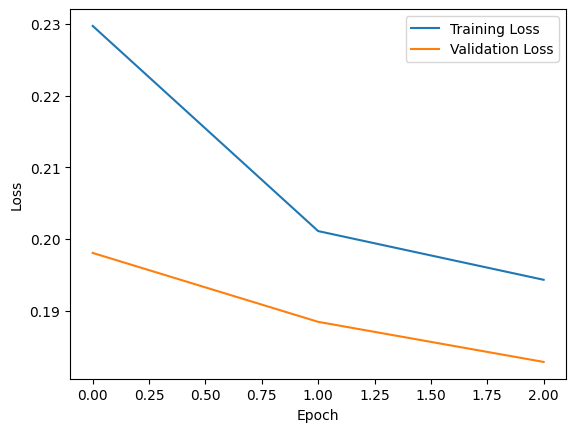

In [19]:
# Plot training and validation loss
plt.plot(fine_tuning_history.history['loss'], label='Training Loss')
plt.plot(fine_tuning_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# If you have custom metrics, you can plot them as well:
if 'F1_score' in history.history:
    plt.plot(fine_tuning_history.history['F1_score'], label='Training F1-score')
    plt.plot(fine_tuning_history.history['val_F1_score'], label='Validation F1-score')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

# Part 3: Training your model Orion

Use the lecture slides from the Orion-lecture to get started.
1. Put one of your model implementations into a python script (`.py`)
2. Transfer that script to Orion.
3. Change the relevant path variables in your python script (path-to-data for example), and make sure that you record the time it takes to train the model in the script. This can be done using the `time` library for example.
4. Set up a SLURM-script to train your model, please use the example from the Orion lecture as a base.
5. Submit your SLURM job, and let the magic happen.

If you wish to use a model trained on Orion to make a Kaggle submission, remember to save the model, such that you can transfer it to your local computer to make a prediction on `X_test`, or test the model on Orion directly if you want to.

## Tips

If you compiled, trained and stored a model on Orion with a custom performance metric (such as F1-score), remember to specify that metric when loading the model on your computer again.

Loading a saved model:
```python
trained_model = tf.keras.models.load_model('some/path/to/my_trained_model.keras', custom_objects={'F1_score': F1_score})
```

Loading a checkpoint:
```python
trained_model = tf.keras.saving.load_model('some/path/to/my_trained_model_checkpoint', custom_objects={'F1_score': F1_score})
```

# Discussion

**Question 1: Which model architectures did you explore, and what type of hyperparameter optimization did you try?**

**Answer 1:** \
We explored a regular U-Net model and a U-Net model with a VGG16 base model. We did a hyperparameter optimization on the number of filters, the dropout rate and the learning rate. 

**Question 2: Which of the model(s) did you choose to train on Orion, and how long did it take to train it on Orion?**

**Answer 2:** \
We cose to train the second U-Net model on Orion. For 20 epochs it took 300 seconds to train the model. However, running the entire file took longer. Training on our local computer with just a CPU would have taken too long, so using Orion significantly improved the process.

**Question 3: What where the biggest challenges with this assignment?**

**Answer 3:** \
A major challenge for us was accessing Orion through Bash, hovewer, it became easier once we familirarized ourself with the system. Transferring files to and from Orion was tricky, we encountered issues loading the trained model back from Orion. Additionally, plotting the trained progress was difficult due to out use of custom F1 score implementation, but we eventually found workarounds. 

# Kaggle submission

Evaluate your best model on the test dataset and submit your prediction to the Kaggle leaderboard.
Link to the Kaggle leaderboard will be posted in the Canvas assignment.

### Kaggle submission

In [ ]:
# Load the model with custom object
trained_model = load_model('my_trained_model.h5', custom_objects={'F1_score': F1_score}, compile=False)

# Compile the model with custom metrics
trained_model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics= metrics
    )

In [ ]:
# Checking if the model is working
evaluation = trained_model.evaluate(X_val, y_val, verbose=1)
print("Evaluation Metrics:", evaluation)

20/20 [==============================] - 4s 140ms/step - loss: 0.1543 - false_negatives: 589880.0000 - false_positives: 865703.0000 - true_negatives: 10571559.0000 - true_positives: 8944378.0000 - f1_score: 0.9226
Evaluation Metrics: [0.15432648360729218, 589880.0, 865703.0, 10571559.0, 8944378.0, 0.9226452708244324]


In [ ]:
# Threshold for sigmoid activation function
USER_DETERMINED_THRESHOLD = 0.5

# We used the first U-Net model on kaggle
y_pred      = trained_model.predict(X_test)  # Make prediction using the trained model
flat_y_pred = y_pred.flatten()                             # Flatten prediction
flat_y_pred[flat_y_pred >= USER_DETERMINED_THRESHOLD] = 1  # Binarize prediction (Optional, depends on output activation used)
flat_y_pred[flat_y_pred != 1]   = 0                        # Binarize prediction (Optional, depends on output activation used)
submissionDF = pd.DataFrame()
submissionDF['ID'] = range(len(flat_y_pred))               # The submission csv file must have a column called 'ID'
submissionDF['Prediction'] = flat_y_pred
submissionDF.to_csv('submission.csv', index=False) # Remember to store the dataframe to csv without the nameless index column.

25/25 [==============================] - 4s 142ms/step


# Appendix
Links to fun and interessting learning resources \
(not so much for this compulsary assignment, more for your own learning and interests):

- <a href="https://streamlit.io/">Streamlit</a>
- <a href="https://github.com/mlabonne/llm-datasets?tab=readme-ov-file">LLM-datasets</a>
- <a href="https://github.com/PacktPublishing/Hands-On-Graph-Neural-Networks-Using-Python">Hands-On Graph Neural Networks Using Python</a>
- <a href="https://github.com/mlabonne/llm-course">LLM Course</a>
- <a href="https://bbycroft.net/llm">LLM by Bycroft</a>
- <a href="https://groq.com/">Groq</a>
- <a href="https://unstructured.io/?fob=kxzdntwfMj4TVNSV">Unstructured.io</a>
- <a href="https://colab.research.google.com/notebooks/tpu.ipynb#scrollTo=a_rjVo-RAoYd">Google Colab TPU Notebook</a>
- <a href="https://github.com/langchain-ai/langgraph/tree/main">LangGraph RAG Agent Llama3 Local</a>
- <a href="https://python.langchain.com/docs/how_to/">LangChain Python Docs</a>
- <a href="https://www.nomic.ai/blog/posts/nomic-embed-text-v1">Nomic Embed Text v1</a>
- <a href="https://duckdb.org/docs/api/python/overview.html">DuckDB Python API Overview</a>
- <a href="https://jsoncrack.com/editor">JSON Crack Editor</a>
- <a href="https://learn.microsoft.com/en-us/azure/data-factory/transform-data-machine-learning-service">Azure Data Factory Machine Learning Service</a>

- <a href="https://learn.microsoft.com/en-us/azure/databricks/machine-learning/">Azure Databricks Machine Learning</a>
- <a href="https://github.com/katanaml">Katana ML - Machine Learning for Business Automation</a>
- <a href="https://deckgl.readthedocs.io/en/latest/">Pydeck - High-scale spatial rendering in Python, powered by deck.gl</a>




